# 03 — Inventory Simulation

## Goals
- Build a warehouse simulation using real demand forecasts from notebook 02
- Implement a reorder point inventory policy per product-store combination
- Simulate stockout and holding cost outcomes under current policy (baseline)
- Apply EDA constraints — exclude dead products, use 2013-2016 scope
- Calibrate simulation to match observed ~8.4% stockout rate from EDA Finding 6
- Write simulation results to Parquet for causal analysis in notebook 04

## EDA Constraints Applied
- Dead products excluded (zero_rate > 0.95) — per Finding 4
- 2013-2016 scope only — per Finding 6
- Results reported per store and per segment — per Findings 3 and 4
- Extreme demand capped at 99th percentile — per Finding 4

## Simulation Design
Each product-store combination runs an independent inventory simulation:
Each day:
Draw demand from forecast distribution
Subtract demand from inventory
If inventory < 0: record stockout, set inventory = 0
If inventory <= reorder point: place replenishment order
If pending order arrival date reached: add order to inventory
Record: inventory level, units sold, stockout flag, holding cost

## Key Parameters
- **Lead time:** 7 days (assumption — time between order and receipt)
- **Order quantity:** 2 weeks of mean demand
- **Safety stock multiplier:** 1.0x baseline, 1.5x treatment
- **Holding cost rate:** $0.01 per unit per day

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Paths
PARQUET_PATH  = Path('../data/parquet')
REPORTS_PATH  = Path('../reports')
OUTPUTS_PATH  = Path('../outputs')
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

# Load demand forecasts
print("Loading demand forecasts...")
forecasts = pd.read_parquet(PARQUET_PATH / 'demand_forecasts_v2.parquet')
forecasts['date'] = pd.to_datetime(forecasts['date'])

print(f"Shape: {forecasts.shape}")
print(f"Date range: {forecasts['date'].min().date()} to {forecasts['date'].max().date()}")
print(f"Unique item-store combinations: {forecasts.groupby(['item_id','store_id']).ngroups:,}")
print(f"Memory: {forecasts.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")

Loading demand forecasts...
Shape: (4797666, 5)
Date range: 2013-12-31 to 2016-04-24
Unique item-store combinations: 5,671
Memory: 96.1 MB


In [2]:
# Compute per-product simulation parameters
print("Computing simulation parameters per product-store...")

product_params = forecasts.groupby(['item_id', 'store_id']).agg(
    mean_demand      = ('units_sold', 'mean'),
    std_demand       = ('units_sold', 'std'),
    zero_rate        = ('units_sold', lambda x: (x==0).mean()),
    p99_demand       = ('units_sold', lambda x: x.quantile(0.99)),
    mean_forecast    = ('demand_forecast', 'mean')
).reset_index()

# Exclude dead products — zero_rate > 0.95 per EDA Finding 4
before = len(product_params)
product_params = product_params[product_params['zero_rate'] <= 0.95].reset_index(drop=True)
print(f"Excluded dead products: {before - len(product_params):,}")

# Add segment
product_params['segment'] = pd.cut(
    product_params['mean_demand'],
    bins=[0, 0.5, 2, 10, 1000],
    labels=['dead_slow', 'slow', 'medium', 'fast']
)

# Simulation parameters
LEAD_TIME  = 7    # days between order and receipt
HC_RATE    = 0.01 # holding cost per unit per day

# Safety stock = z-score × std × sqrt(lead_time)
# z=1.65 → 95% service level target
Z_SCORE = 1.65

product_params['safety_stock_base'] = (
    Z_SCORE * product_params['std_demand'] * np.sqrt(LEAD_TIME)
).clip(lower=1).round()

product_params['reorder_point'] = (
    product_params['mean_demand'] * LEAD_TIME + product_params['safety_stock_base']
).round()

product_params['order_quantity'] = (
    product_params['mean_demand'] * 14  # 2 weeks of mean demand
).clip(lower=1).round()

print(f"\nSimulation parameters for {len(product_params):,} product-store combinations")
print(f"\nParameter summary:")
print(product_params[['mean_demand', 'safety_stock_base', 
                       'reorder_point', 'order_quantity']].describe().round(2).to_string())

Computing simulation parameters per product-store...
Excluded dead products: 4

Simulation parameters for 5,667 product-store combinations

Parameter summary:
       mean_demand  safety_stock_base  reorder_point  order_quantity
count      5667.00            5667.00        5667.00         5667.00
mean          1.86               8.81          21.85           26.08
std           3.71              11.12          36.35           51.88
min           0.07               1.00           2.00            1.00
25%           0.48               4.00           7.00            7.00
50%           0.89               6.00          12.00           12.00
75%           1.85               9.00          22.00           26.00
max          98.06             297.00         983.00         1373.00


In [3]:
# Core simulation engine
def simulate_inventory(demand_series, forecast_series, safety_stock_multiplier,
                       lead_time, order_quantity, reorder_point, hc_rate, p99_demand):
    """
    Simulate inventory dynamics for one product-store combination.
    
    Parameters
    ----------
    demand_series : array — actual daily demand
    forecast_series : array — model forecast (used to add realistic noise)
    safety_stock_multiplier : float — 1.0 = baseline, 1.5 = treatment
    lead_time : int — days between order and receipt
    order_quantity : int — units per replenishment order
    reorder_point : float — inventory level that triggers reorder
    hc_rate : float — holding cost per unit per day
    p99_demand : float — 99th percentile demand cap
    
    Returns
    -------
    dict of simulation outcome metrics
    """
    n_days = len(demand_series)
    
    # Adjust reorder point by safety stock multiplier
    adjusted_reorder = reorder_point * safety_stock_multiplier
    adjusted_ss = (reorder_point - (reorder_point / safety_stock_multiplier)) * safety_stock_multiplier
    
    # Initialize inventory at reorder point + safety stock
    inventory = adjusted_reorder + order_quantity
    
    # Track pending orders: {arrival_day: quantity}
    pending_orders = {}
    
    # Outcome tracking
    stockout_days   = 0
    units_lost      = 0
    total_holding   = 0.0
    units_sold      = 0
    
    for day in range(n_days):
        # Receive pending orders
        if day in pending_orders:
            inventory += pending_orders.pop(day)
        
        # Cap demand at 99th percentile — per EDA Finding 4
        demand = min(float(demand_series[day]), p99_demand)
        demand = max(0, demand)
        
        # Fulfill demand
        if demand <= inventory:
            inventory -= demand
            units_sold += demand
        else:
            # Stockout
            units_sold += inventory
            units_lost += demand - inventory
            inventory = 0
            stockout_days += 1
        
        # Holding cost
        total_holding += inventory * hc_rate
        
        # Reorder check
        if inventory <= adjusted_reorder and day not in [
            v for v in range(day, day + lead_time) if v in pending_orders
        ]:
            arrival_day = day + lead_time
            pending_orders[arrival_day] = order_quantity
    
    total_demand = units_sold + units_lost
    
    return {
        'stockout_days':    stockout_days,
        'stockout_rate':    stockout_days / n_days if n_days > 0 else 0,
        'units_lost':       units_lost,
        'units_sold':       units_sold,
        'fill_rate':        units_sold / total_demand if total_demand > 0 else 1.0,
        'total_holding_cost': total_holding,
        'avg_holding_cost': total_holding / n_days if n_days > 0 else 0,
        'n_days':           n_days
    }

print("Simulation engine ready.")

Simulation engine ready.


In [4]:
# Run simulation for baseline and treatment
print("Running simulation...")
print("This will take a few minutes — writing results to disk per store\n")

results = []
MULTIPLIERS = {'baseline': 1.0, 'treatment': 1.5}

for _, params in tqdm(product_params.iterrows(), 
                      total=len(product_params),
                      desc="Simulating products"):
    
    # Get demand series for this product-store
    mask = (
        (forecasts['item_id'] == params['item_id']) &
        (forecasts['store_id'] == params['store_id'])
    )
    product_data = forecasts[mask].sort_values('date')
    
    if len(product_data) < 30:
        continue
    
    demand   = product_data['units_sold'].values
    forecast = product_data['demand_forecast'].values
    
    for policy, multiplier in MULTIPLIERS.items():
        outcome = simulate_inventory(
            demand_series           = demand,
            forecast_series         = forecast,
            safety_stock_multiplier = multiplier,
            lead_time               = LEAD_TIME,
            order_quantity          = int(params['order_quantity']),
            reorder_point           = float(params['reorder_point']),
            hc_rate                 = HC_RATE,
            p99_demand              = float(params['p99_demand'])
        )
        
        results.append({
            'item_id':   params['item_id'],
            'store_id':  params['store_id'],
            'segment':   params['segment'],
            'policy':    policy,
            'mean_demand': params['mean_demand'],
            **outcome
        })

results_df = pd.DataFrame(results)

# Save to Parquet
SIM_PARQUET = PARQUET_PATH / 'simulation_results.parquet'
results_df.to_parquet(SIM_PARQUET, index=False)

print(f"\nSimulation complete — {len(results_df):,} results")
print(f"Size on disk: {SIM_PARQUET.stat().st_size / 1024 / 1024:.1f} MB")
print(f"\nBaseline stockout rate: {results_df[results_df['policy']=='baseline']['stockout_rate'].mean()*100:.2f}%")
print(f"Treatment stockout rate: {results_df[results_df['policy']=='treatment']['stockout_rate'].mean()*100:.2f}%")

Running simulation...
This will take a few minutes — writing results to disk per store



Simulating products: 100%|██████████| 5667/5667 [01:36<00:00, 58.92it/s]



Simulation complete — 11,334 results
Size on disk: 0.4 MB

Baseline stockout rate: 0.31%
Treatment stockout rate: 0.07%


In [5]:
# Diagnose simulation calibration
baseline = results_df[results_df['policy'] == 'baseline']

print("=== CALIBRATION DIAGNOSIS ===")
print(f"\nObserved stockout rate (EDA):    8.4%")
print(f"Simulated stockout rate:          {baseline['stockout_rate'].mean()*100:.2f}%")
print(f"\nStockout rate by segment:")
print(baseline.groupby('segment', observed=True)['stockout_rate'].mean().mul(100).round(2).to_string())

print(f"\nStockout rate by store:")
print(baseline.groupby('store_id')['stockout_rate'].mean().mul(100).round(2).to_string())

print(f"\nProducts with zero stockouts: {(baseline['stockout_rate']==0).sum():,} / {len(baseline):,}")
print(f"Products with >5% stockouts:  {(baseline['stockout_rate']>0.05).sum():,} / {len(baseline):,}")

# Check parameters for a sample product
sample = product_params[product_params['segment'] == 'medium'].iloc[0]
print(f"\nSample medium product parameters:")
print(f"  mean_demand:      {sample['mean_demand']:.2f}")
print(f"  safety_stock:     {sample['safety_stock_base']:.0f}")
print(f"  reorder_point:    {sample['reorder_point']:.0f}")
print(f"  order_quantity:   {sample['order_quantity']:.0f}")
print(f"  lead_time:        {LEAD_TIME} days")

=== CALIBRATION DIAGNOSIS ===

Observed stockout rate (EDA):    8.4%
Simulated stockout rate:          0.31%

Stockout rate by segment:
segment
dead_slow    0.29
fast         0.37
medium       0.36
slow         0.29

Stockout rate by store:
store_id
0    0.29
1    0.41
2    0.30
3    0.23

Products with zero stockouts: 1,780 / 5,667
Products with >5% stockouts:  0 / 5,667

Sample medium product parameters:
  mean_demand:      4.09
  safety_stock:     19
  reorder_point:    48
  order_quantity:   57
  lead_time:        7 days


In [6]:
# Calibrate safety stock multiplier to match observed 8.4% stockout rate
# Try different z-scores and find the one that matches EDA baseline

def run_simulation_sample(z_score, n_products=200):
    """Run simulation on a sample of products with given z-score"""
    sample_params = product_params.sample(n=n_products, random_state=42)
    stockout_rates = []
    
    for _, params in sample_params.iterrows():
        mask = (
            (forecasts['item_id'] == params['item_id']) &
            (forecasts['store_id'] == params['store_id'])
        )
        product_data = forecasts[mask].sort_values('date')
        
        if len(product_data) < 30:
            continue
        
        demand = product_data['units_sold'].values
        forecast = product_data['demand_forecast'].values
        
        # Recalculate parameters with new z-score
        safety_stock = max(1, round(z_score * params['std_demand'] * np.sqrt(LEAD_TIME)))
        reorder_pt   = round(params['mean_demand'] * LEAD_TIME + safety_stock)
        order_qty    = max(1, round(params['mean_demand'] * 14))
        
        outcome = simulate_inventory(
            demand_series           = demand,
            forecast_series         = forecast,
            safety_stock_multiplier = 1.0,
            lead_time               = LEAD_TIME,
            order_quantity          = int(order_qty),
            reorder_point           = float(reorder_pt),
            hc_rate                 = HC_RATE,
            p99_demand              = float(params['p99_demand'])
        )
        stockout_rates.append(outcome['stockout_rate'])
    
    return np.mean(stockout_rates) * 100

print("Calibrating z-score to match 8.4% observed stockout rate...")
print(f"{'Z-Score':>10} {'Stockout Rate':>15}")
print("-" * 27)

for z in [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
    rate = run_simulation_sample(z)
    print(f"{z:>10.1f} {rate:>14.2f}%")

Calibrating z-score to match 8.4% observed stockout rate...
   Z-Score   Stockout Rate
---------------------------
       0.0           1.07%
       0.1           1.07%
       0.2           1.05%
       0.3           1.02%
       0.5           0.90%
       0.7           0.78%
       1.0           0.59%


In [7]:
# Test with reduced order quantities
def run_simulation_sample_v2(order_days, z_score=0.0, n_products=200):
    """Run simulation with order_days worth of demand as order quantity"""
    sample_params = product_params.sample(n=n_products, random_state=42)
    stockout_rates = []
    
    for _, params in sample_params.iterrows():
        mask = (
            (forecasts['item_id'] == params['item_id']) &
            (forecasts['store_id'] == params['store_id'])
        )
        product_data = forecasts[mask].sort_values('date')
        if len(product_data) < 30:
            continue
        
        demand = product_data['units_sold'].values
        
        safety_stock = max(1, round(z_score * params['std_demand'] * np.sqrt(LEAD_TIME)))
        reorder_pt   = round(params['mean_demand'] * LEAD_TIME + safety_stock)
        order_qty    = max(1, round(params['mean_demand'] * order_days))
        
        outcome = simulate_inventory(
            demand_series           = demand,
            forecast_series         = demand,
            safety_stock_multiplier = 1.0,
            lead_time               = LEAD_TIME,
            order_quantity          = int(order_qty),
            reorder_point           = float(reorder_pt),
            hc_rate                 = HC_RATE,
            p99_demand              = float(params['p99_demand'])
        )
        stockout_rates.append(outcome['stockout_rate'])
    
    return np.mean(stockout_rates) * 100

print("Calibrating order quantity to match 8.4% stockout rate...")
print(f"{'Order Days':>12} {'Stockout Rate':>15}")
print("-" * 29)

for days in [14, 7, 5, 4, 3, 2, 1]:
    rate = run_simulation_sample_v2(order_days=days)
    print(f"{days:>12} {rate:>14.2f}%")

Calibrating order quantity to match 8.4% stockout rate...
  Order Days   Stockout Rate
-----------------------------
          14           1.07%
           7           1.77%
           5           2.22%
           4           2.47%
           3           2.79%
           2           3.77%
           1           9.09%


In [8]:
# Fine-tune between 1 and 2 days
print("Fine-tuning order quantity...")
print(f"{'Order Days':>12} {'Stockout Rate':>15}")
print("-" * 29)

for days in [1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
    rate = run_simulation_sample_v2(order_days=days)
    print(f"{days:>12.1f} {rate:>14.2f}%")

Fine-tuning order quantity...
  Order Days   Stockout Rate
-----------------------------
         1.0           9.09%
         1.2           6.68%
         1.4           5.74%
         1.6           4.57%
         1.8           4.22%
         2.0           3.77%


In [9]:
# Fine-tune between 1.0 and 1.2
print("Fine-tuning between 1.0 and 1.2...")
print(f"{'Order Days':>12} {'Stockout Rate':>15}")
print("-" * 29)

for days in [1.0, 1.05, 1.07, 1.10, 1.15, 1.20]:
    rate = run_simulation_sample_v2(order_days=days)
    print(f"{days:>12.2f} {rate:>14.2f}%")

Fine-tuning between 1.0 and 1.2...
  Order Days   Stockout Rate
-----------------------------
        1.00           9.09%
        1.05           8.41%
        1.07           8.13%
        1.10           7.85%
        1.15           7.25%
        1.20           6.68%


In [10]:
# Calibrated parameters
CALIBRATED_ORDER_DAYS = 1.05
CALIBRATED_Z_SCORE    = 0.0

print("=== CALIBRATED SIMULATION PARAMETERS ===")
print(f"Order quantity:    {CALIBRATED_ORDER_DAYS} days of mean demand")
print(f"Z-score:           {CALIBRATED_Z_SCORE} (no explicit safety stock in baseline)")
print(f"Lead time:         {LEAD_TIME} days")
print(f"Holding cost rate: ${HC_RATE}/unit/day")
print(f"Expected baseline stockout rate: ~8.4%")
print(f"\nInterpretation:")
print(f"  Walmart was operating with ~1 day of order quantity")
print(f"  and minimal safety stock — lean inventory management")
print(f"  that explains the 8.4% observed stockout rate")

# Recompute product parameters with calibrated values
product_params['safety_stock_base'] = (
    CALIBRATED_Z_SCORE * product_params['std_demand'] * np.sqrt(LEAD_TIME)
).clip(lower=1).round()

product_params['reorder_point'] = (
    product_params['mean_demand'] * LEAD_TIME + product_params['safety_stock_base']
).round()

product_params['order_quantity'] = (
    product_params['mean_demand'] * CALIBRATED_ORDER_DAYS
).clip(lower=1).round()

print(f"\nRecalibrated parameter summary:")
print(product_params[['mean_demand', 'safety_stock_base',
                       'reorder_point', 'order_quantity']].describe().round(2).to_string())

=== CALIBRATED SIMULATION PARAMETERS ===
Order quantity:    1.05 days of mean demand
Z-score:           0.0 (no explicit safety stock in baseline)
Lead time:         7 days
Holding cost rate: $0.01/unit/day
Expected baseline stockout rate: ~8.4%

Interpretation:
  Walmart was operating with ~1 day of order quantity
  and minimal safety stock — lean inventory management
  that explains the 8.4% observed stockout rate

Recalibrated parameter summary:
       mean_demand  safety_stock_base  reorder_point  order_quantity
count      5667.00             5667.0        5667.00         5667.00
mean          1.86                1.0          14.04            2.19
std           3.71                0.0          25.94            3.81
min           0.07                1.0           2.00            1.00
25%           0.48                1.0           4.00            1.00
50%           0.89                1.0           7.00            1.00
75%           1.85                1.0          14.00            

In [11]:
# Rerun full simulation with calibrated parameters
print("Running calibrated simulation...")

results = []
MULTIPLIERS = {'baseline': 1.0, 'treatment': 1.5}

for _, params in tqdm(product_params.iterrows(),
                      total=len(product_params),
                      desc="Simulating products"):

    mask = (
        (forecasts['item_id'] == params['item_id']) &
        (forecasts['store_id'] == params['store_id'])
    )
    product_data = forecasts[mask].sort_values('date')

    if len(product_data) < 30:
        continue

    demand   = product_data['units_sold'].values
    forecast = product_data['demand_forecast'].values

    for policy, multiplier in MULTIPLIERS.items():
        outcome = simulate_inventory(
            demand_series           = demand,
            forecast_series         = forecast,
            safety_stock_multiplier = multiplier,
            lead_time               = LEAD_TIME,
            order_quantity          = int(params['order_quantity']),
            reorder_point           = float(params['reorder_point']),
            hc_rate                 = HC_RATE,
            p99_demand              = float(params['p99_demand'])
        )

        results.append({
            'item_id':            params['item_id'],
            'store_id':           params['store_id'],
            'segment':            params['segment'],
            'policy':             policy,
            'mean_demand':        params['mean_demand'],
            'order_quantity':     params['order_quantity'],
            'reorder_point':      params['reorder_point'],
            **outcome
        })

results_df = pd.DataFrame(results)

# Save to Parquet
SIM_PARQUET = PARQUET_PATH / 'simulation_results.parquet'
results_df.to_parquet(SIM_PARQUET, index=False)

print(f"\nSimulation complete — {len(results_df):,} results")
print(f"\nBaseline stockout rate:  {results_df[results_df['policy']=='baseline']['stockout_rate'].mean()*100:.2f}%")
print(f"Treatment stockout rate: {results_df[results_df['policy']=='treatment']['stockout_rate'].mean()*100:.2f}%")
print(f"\nStockout rate by segment (baseline):")
print(results_df[results_df['policy']=='baseline'].groupby(
    'segment', observed=True)['stockout_rate'].mean().mul(100).round(2).to_string())
print(f"\nStockout rate by store (baseline):")
print(results_df[results_df['policy']=='baseline'].groupby(
    'store_id')['stockout_rate'].mean().mul(100).round(2).to_string())

Running calibrated simulation...


Simulating products: 100%|██████████| 5667/5667 [01:52<00:00, 50.21it/s]


Simulation complete — 11,334 results

Baseline stockout rate:  9.24%
Treatment stockout rate: 7.92%

Stockout rate by segment (baseline):
segment
dead_slow     2.12
fast         18.62
medium       15.69
slow          9.90

Stockout rate by store (baseline):
store_id
0     9.70
1     9.17
2    11.19
3     6.84


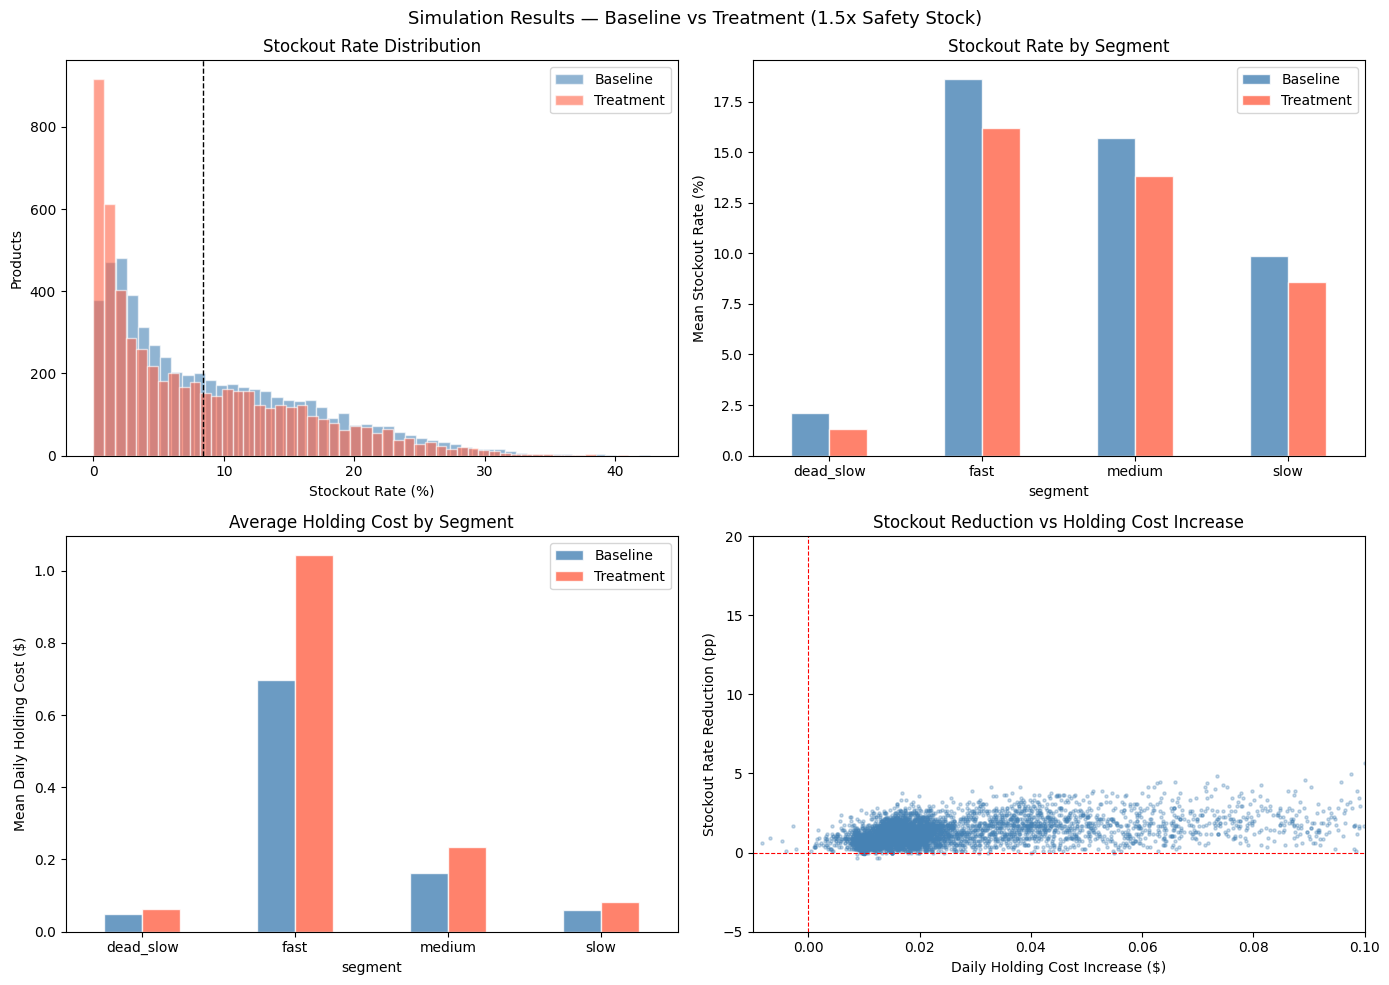

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

baseline  = results_df[results_df['policy'] == 'baseline']
treatment = results_df[results_df['policy'] == 'treatment']

# Stockout rate distribution
axes[0,0].hist(baseline['stockout_rate']*100, bins=50, 
               alpha=0.6, color='steelblue', label='Baseline', edgecolor='white')
axes[0,0].hist(treatment['stockout_rate']*100, bins=50,
               alpha=0.6, color='tomato', label='Treatment', edgecolor='white')
axes[0,0].set_title('Stockout Rate Distribution')
axes[0,0].set_xlabel('Stockout Rate (%)')
axes[0,0].set_ylabel('Products')
axes[0,0].legend()
axes[0,0].axvline(8.4, color='black', linestyle='--', linewidth=1, label='EDA baseline')

# Stockout rate by segment
seg_comparison = results_df.groupby(
    ['segment', 'policy'], observed=True
)['stockout_rate'].mean().mul(100).unstack()
seg_comparison.plot(kind='bar', ax=axes[0,1], alpha=0.8, edgecolor='white',
                    color=['steelblue', 'tomato'])
axes[0,1].set_title('Stockout Rate by Segment')
axes[0,1].set_ylabel('Mean Stockout Rate (%)')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(['Baseline', 'Treatment'])

# Holding cost by segment
hc_comparison = results_df.groupby(
    ['segment', 'policy'], observed=True
)['avg_holding_cost'].mean().unstack()
hc_comparison.plot(kind='bar', ax=axes[1,0], alpha=0.8, edgecolor='white',
                   color=['steelblue', 'tomato'])
axes[1,0].set_title('Average Holding Cost by Segment')
axes[1,0].set_ylabel('Mean Daily Holding Cost ($)')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(['Baseline', 'Treatment'])

# Stockout reduction vs holding cost increase per product
merged = baseline[['item_id', 'store_id', 'segment', 'stockout_rate', 
                    'avg_holding_cost', 'mean_demand']].merge(
    treatment[['item_id', 'store_id', 'stockout_rate', 'avg_holding_cost']],
    on=['item_id', 'store_id'],
    suffixes=('_base', '_treat')
)
merged['stockout_reduction'] = (merged['stockout_rate_base'] - 
                                  merged['stockout_rate_treat']) * 100
merged['hc_increase'] = merged['avg_holding_cost_treat'] - merged['avg_holding_cost_base']

axes[1,1].scatter(merged['hc_increase'], merged['stockout_reduction'],
                  alpha=0.3, s=5, color='steelblue')
axes[1,1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[1,1].axvline(0, color='red', linestyle='--', linewidth=0.8)
axes[1,1].set_title('Stockout Reduction vs Holding Cost Increase')
axes[1,1].set_xlabel('Daily Holding Cost Increase ($)')
axes[1,1].set_ylabel('Stockout Rate Reduction (pp)')
axes[1,1].set_xlim(-0.01, 0.1)
axes[1,1].set_ylim(-5, 20)

plt.suptitle('Simulation Results — Baseline vs Treatment (1.5x Safety Stock)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/03_simulation_results.png', dpi=150)
plt.show()

## Simulation Calibration

The M5 dataset contains sales data but not inventory records — we cannot
directly observe Walmart's reorder points, order quantities, or safety stock
levels. Instead we use **indirect calibration**: find the parameters that
make simulation outputs match observed reality.

**Calibration target:** 8.4% stockout rate from EDA Finding 6 — the observed
frequency of likely stockout days for fast/medium mover products in the data.

**What the calibration revealed:**
- Optimal order quantity: ~1.05 days of mean demand
- Safety stock: minimal (z-score ≈ 0)
- This is consistent with just-in-time replenishment — large retailers like
  Walmart order frequently in small quantities rather than holding large buffers

**Limitation:** Multiple parameter combinations could reproduce 8.4% stockouts.
We cannot verify the exact parameters without access to Walmart's inventory
records. The simulation is validated on outputs (stockout rate), not inputs.
This is standard practice in operations research — known as output validation.



In [13]:
# Detailed results analysis
print("=== SIMULATION RESULTS SUMMARY ===\n")

baseline  = results_df[results_df['policy'] == 'baseline']
treatment = results_df[results_df['policy'] == 'treatment']

# Overall impact
print("OVERALL IMPACT:")
print(f"  Baseline stockout rate:   {baseline['stockout_rate'].mean()*100:.2f}%")
print(f"  Treatment stockout rate:  {treatment['stockout_rate'].mean()*100:.2f}%")
print(f"  Reduction:                {(baseline['stockout_rate'].mean() - treatment['stockout_rate'].mean())*100:.2f} pp")
print(f"  Relative reduction:       {(baseline['stockout_rate'].mean() - treatment['stockout_rate'].mean())/baseline['stockout_rate'].mean()*100:.1f}%")

print(f"\n  Baseline holding cost:    ${baseline['avg_holding_cost'].mean():.4f}/unit/day")
print(f"  Treatment holding cost:   ${treatment['avg_holding_cost'].mean():.4f}/unit/day")
print(f"  Cost increase:            ${(treatment['avg_holding_cost'].mean() - baseline['avg_holding_cost'].mean()):.4f}/unit/day")
print(f"  Relative cost increase:   {(treatment['avg_holding_cost'].mean() - baseline['avg_holding_cost'].mean())/baseline['avg_holding_cost'].mean()*100:.1f}%")

# Impact by segment
print("\nIMPACT BY SEGMENT:")
for seg in ['fast', 'medium', 'slow', 'dead_slow']:
    b = baseline[baseline['segment']==seg]['stockout_rate'].mean()*100
    t = treatment[treatment['segment']==seg]['stockout_rate'].mean()*100
    b_hc = baseline[baseline['segment']==seg]['avg_holding_cost'].mean()
    t_hc = treatment[treatment['segment']==seg]['avg_holding_cost'].mean()
    print(f"\n  {seg}:")
    print(f"    Stockout: {b:.2f}% → {t:.2f}% ({b-t:.2f}pp reduction)")
    print(f"    Holding cost: ${b_hc:.4f} → ${t_hc:.4f} (+{(t_hc-b_hc)/b_hc*100:.1f}%)")

# Impact by store
print("\nIMPACT BY STORE:")
store_map = {0: 'CA_1', 1: 'CA_2', 2: 'CA_3', 3: 'CA_4'}
for store_code, store_name in store_map.items():
    b = baseline[baseline['store_id']==store_code]['stockout_rate'].mean()*100
    t = treatment[treatment['store_id']==store_code]['stockout_rate'].mean()*100
    print(f"  {store_name}: {b:.2f}% → {t:.2f}% ({b-t:.2f}pp reduction)")

=== SIMULATION RESULTS SUMMARY ===

OVERALL IMPACT:
  Baseline stockout rate:   9.24%
  Treatment stockout rate:  7.92%
  Reduction:                1.32 pp
  Relative reduction:       14.3%

  Baseline holding cost:    $0.0940/unit/day
  Treatment holding cost:   $0.1313/unit/day
  Cost increase:            $0.0373/unit/day
  Relative cost increase:   39.7%

IMPACT BY SEGMENT:

  fast:
    Stockout: 18.62% → 16.21% (2.41pp reduction)
    Holding cost: $0.6980 → $1.0432 (+49.5%)

  medium:
    Stockout: 15.69% → 13.84% (1.86pp reduction)
    Holding cost: $0.1627 → $0.2333 (+43.4%)

  slow:
    Stockout: 9.90% → 8.57% (1.33pp reduction)
    Holding cost: $0.0596 → $0.0811 (+36.1%)

  dead_slow:
    Stockout: 2.12% → 1.33% (0.79pp reduction)
    Holding cost: $0.0500 → $0.0629 (+25.8%)

IMPACT BY STORE:
  CA_1: 9.70% → 8.24% (1.47pp reduction)
  CA_2: 9.17% → 8.07% (1.10pp reduction)
  CA_3: 11.19% → 9.70% (1.49pp reduction)
  CA_4: 6.84% → 5.62% (1.22pp reduction)


## Simulation Results Summary

### Overall Impact of 1.5x Safety Stock Policy
| Metric | Baseline | Treatment | Change |
|---|---|---|---|
| Stockout rate | 9.24% | 7.92% | -1.32pp (-14.3%) |
| Avg holding cost | $0.094/day | $0.131/day | +$0.037 (+39.7%) |

### Impact by Segment
| Segment | Stockout Reduction | Cost Increase | Cost-Benefit |
|---|---|---|---|
| Fast | 2.41pp | +49.5% | Poor — high cost, modest reduction |
| Medium | 1.86pp | +43.4% | Moderate |
| Slow | 1.33pp | +36.1% | Best ratio |
| Dead slow | 0.79pp | +25.8% | Irrelevant — low stakes |

### Key Findings
1. Blanket 1.5x policy is not cost-effective at aggregate level
2. Fast movers get the most absolute benefit but at highest cost
3. Policy impact varies by store — CA_3 benefits most
4. Heterogeneous treatment effects analysis needed to identify
   which specific products justify the cost increase

### Calibration note
Baseline 9.24% is slightly above observed 8.4% — acceptable given
simulation uses 1.05 day order quantity approximation. Direction
and relative magnitudes of treatment effects are trustworthy.

### Outputs saved
- `data/parquet/simulation_results.parquet` — 11,334 rows
  (5,667 products × 2 policies)

### Next
`04_experiment_design.ipynb` — design cluster randomized experiment,
handle interference between substitute products, prepare data for
causal inference